# Cancer Transcription Factor Discovery Pipeline

This notebook walks through a complete machine learning pipeline to predict cancer cell growth using protein expression and gene expression data, and to identify which transcription factors (TFs) are most strongly associated with cancer.

**Dataset overview**
- `gene_expression.csv`: expression levels for 68 genes (20 TFs + 48 others) across 1,200 cells
- `protein_expression.csv`: expression levels for 80 proteins across 1,200 cells
- `cell_labels.csv`: binary label per cell (0 = normal, 1 = cancer)
- `tf_annotation.csv`: list of known transcription factor gene symbols

**Steps in this notebook**
1. Load and inspect data
2. Exploratory data analysis (EDA)
3. Merge features and prepare the model matrix
4. Train/test split and feature scaling
5. Train a Random Forest classifier
6. Evaluate model performance
7. Rank transcription factors by importance
8. Visualize results

## Step 1: Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

# Consistent plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print('All libraries loaded successfully.')

All libraries loaded successfully.


## Step 2: Load data

We will load all four of our csvs.

In [2]:
gene_df   = pd.read_csv('gene_expression.csv',    index_col='cell_id')
prot_df   = pd.read_csv('protein_expression.csv', index_col='cell_id')
label_df  = pd.read_csv('cell_labels.csv',        index_col='cell_id')
tf_annot  = pd.read_csv('tf_annotation.csv')

print('gene_expression   :', gene_df.shape)
print('protein_expression:', prot_df.shape)
print('cell_labels       :', label_df.shape)
print('tf_annotation     :', tf_annot.shape)

print('\nLabel distribution:')
print(label_df['label'].value_counts().rename({0: 'Normal', 1: 'Cancer'}))

gene_expression   : (1200, 68)
protein_expression: (1200, 80)
cell_labels       : (1200, 1)
tf_annotation     : (20, 2)

Label distribution:
label
Normal    600
Cancer    600
Name: count, dtype: int64


In [3]:
# Quick look at gene expression data
gene_df.head(3)

,TP53,MYC,HIF1A,FOXM1,E2F1,NFKB1,SP1,STAT3,AP1,RUNX1,...,GENE_039,GENE_040,GENE_041,GENE_042,GENE_043,GENE_044,GENE_045,GENE_046,GENE_047,GENE_048
cell_id,,,,,,,,,,,,,,,,,,,,,
CELL_0648,0.722027,0.700896,1.824509,1.792093,1.200201,0.866788,0.937381,0.851560,2.061370,1.039529,...,1.471771,1.515740,1.418079,0.682539,1.234718,1.479677,3.055945,1.436360,1.138595,1.597619
CELL_0440,2.239229,4.403388,4.823113,1.885390,1.856020,3.287419,3.864160,2.665449,3.942116,2.261312,...,1.792736,0.782932,1.152589,2.325864,3.312130,1.681956,1.240325,1.050537,2.128414,2.379055
CELL_0532,2.538435,3.593664,3.607049,5.160862,4.851511,2.679910,5.052830,2.257783,4.359489,6.197890,...,1.384126,1.171616,1.639286,1.054932,0.553155,0.848860,0.799372,0.605283,1.623688,1.238148


In [4]:
# Quick look at protein expression data
prot_df.head(3)

,PROT_001,PROT_002,PROT_003,PROT_004,PROT_005,PROT_006,PROT_007,PROT_008,PROT_009,PROT_010,...,PROT_071,PROT_072,PROT_073,PROT_074,PROT_075,PROT_076,PROT_077,PROT_078,PROT_079,PROT_080
cell_id,,,,,,,,,,,,,,,,,,,,,
CELL_0648,1.090564,1.508494,1.192090,0.989511,0.976557,1.879647,1.275842,1.848876,0.998348,1.718260,...,1.679068,1.885911,1.157076,1.494518,1.196918,1.339940,1.336594,1.813873,1.502645,0.921641
CELL_0440,2.242903,1.078529,1.331578,1.110991,1.149577,1.012145,1.159964,2.218242,3.466269,0.988495,...,2.194081,0.946401,3.679990,0.998210,1.423119,2.114132,5.441093,3.041860,2.681941,5.007801
CELL_0532,6.158002,2.679606,4.965079,3.405899,6.248412,2.144342,1.489569,3.560027,0.868838,3.184095,...,3.383609,3.866999,2.797307,1.808165,3.163037,1.210890,4.915288,1.477782,6.600000,1.916667


In [5]:
# Transcription factor annotation
print('Transcription factors in annotation file:')
print(tf_annot.to_string(index=False))

Transcription factors in annotation file:
gene_symbol   tf_family
       TP53         p53
        MYC        bHLH
      HIF1A        bHLH
      FOXM1    Forkhead
       E2F1         E2F
      NFKB1         Rel
        SP1      SP/KLF
      STAT3        STAT
        AP1        AP-1
      RUNX1        Runt
      SMAD3        SMAD
       YAP1        TEAD
     CTNNB1         HMG
    EGFR_TF      RTK-TF
     TWIST1        bHLH
       ZEB1 Zinc finger
      SNAI1 Zinc finger
       KLF4      SP/KLF
       SOX2         HMG
       OCT4         POU


## Step 3: Exploratory data analysis

Before training the model,we will understand the distribution of expression values and how TFs differ between cancer and normal cells.

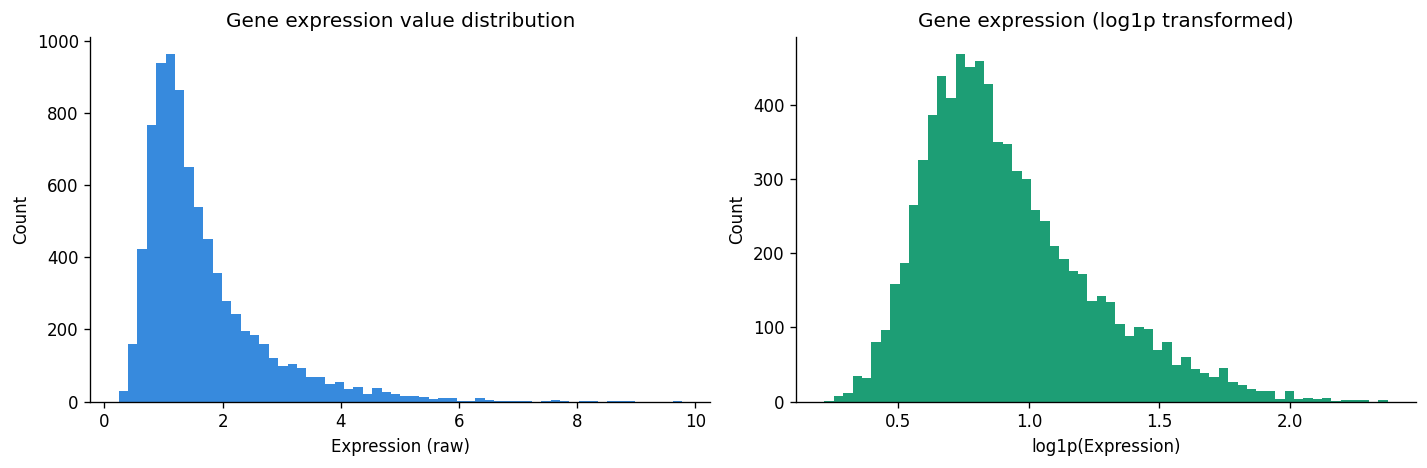

In [6]:
# Overall distribution of gene expression values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

gene_df.values.flatten()[::10]  # sample every 10th to keep it fast
axes[0].hist(gene_df.values.flatten()[::10], bins=60, color='#378ADD', edgecolor='none')
axes[0].set_title('Gene expression value distribution')
axes[0].set_xlabel('Expression (raw)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(gene_df.values.flatten()[::10]), bins=60, color='#1D9E75', edgecolor='none')
axes[1].set_title('Gene expression (log1p transformed)')
axes[1].set_xlabel('log1p(Expression)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [7]:
# Identify TF columns present in the gene data
tf_symbols = tf_annot['gene_symbol'].tolist()
tf_cols_in_data = [c for c in gene_df.columns if c in tf_symbols]
print(f'{len(tf_cols_in_data)} transcription factors found in gene expression data:')
print(tf_cols_in_data)

20 transcription factors found in gene expression data:
['TP53', 'MYC', 'HIF1A', 'FOXM1', 'E2F1', 'NFKB1', 'SP1', 'STAT3', 'AP1', 'RUNX1', 'SMAD3', 'YAP1', 'CTNNB1', 'EGFR_TF', 'TWIST1', 'ZEB1', 'SNAI1', 'KLF4', 'SOX2', 'OCT4']


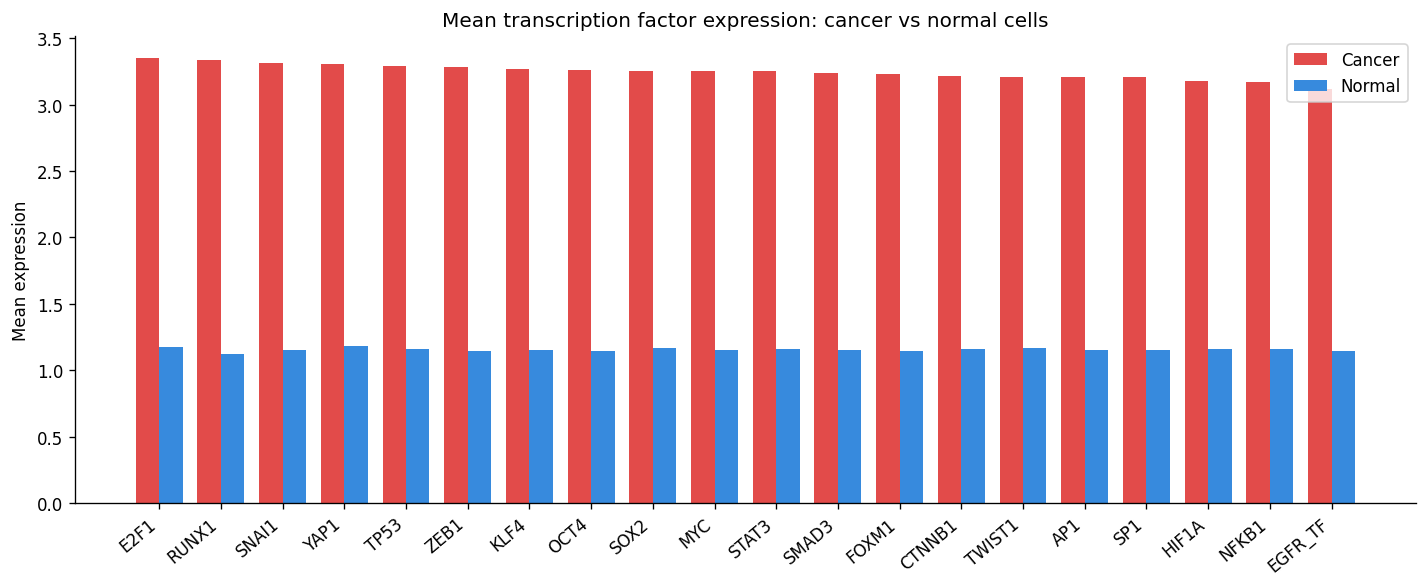

In [8]:
# Compare mean TF expression in cancer vs normal cells
labels = label_df['label']

cancer_mean = gene_df.loc[labels == 1, tf_cols_in_data].mean()
normal_mean = gene_df.loc[labels == 0, tf_cols_in_data].mean()

tf_compare = pd.DataFrame({
    'Cancer mean': cancer_mean,
    'Normal mean': normal_mean
}).sort_values('Cancer mean', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(tf_compare))
width = 0.38
ax.bar(x - width/2, tf_compare['Cancer mean'], width, label='Cancer', color='#E24B4A')
ax.bar(x + width/2, tf_compare['Normal mean'], width, label='Normal', color='#378ADD')
ax.set_xticks(x)
ax.set_xticklabels(tf_compare.index, rotation=40, ha='right')
ax.set_ylabel('Mean expression')
ax.set_title('Mean transcription factor expression: cancer vs normal cells')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# Fold change: how much higher is each TF in cancer vs normal
tf_compare['Fold change (cancer/normal)'] = (tf_compare['Cancer mean'] / tf_compare['Normal mean']).round(3)
print(tf_compare.sort_values('Fold change (cancer/normal)', ascending=False).to_string())

         Cancer mean  Normal mean  Fold change (cancer/normal)
RUNX1       3.334254     1.123498                        2.968
ZEB1        3.283780     1.142758                        2.874
SNAI1       3.316788     1.155351                        2.871
E2F1        3.349459     1.171231                        2.860
OCT4        3.260072     1.146760                        2.843
TP53        3.291668     1.157800                        2.843
KLF4        3.265750     1.149148                        2.842
FOXM1       3.230224     1.142429                        2.828
MYC         3.253757     1.154631                        2.818
STAT3       3.253724     1.157785                        2.810
SMAD3       3.239162     1.154409                        2.806
SOX2        3.255312     1.163649                        2.798
YAP1        3.308059     1.183128                        2.796
AP1         3.207381     1.150639                        2.787
SP1         3.204409     1.151822                      

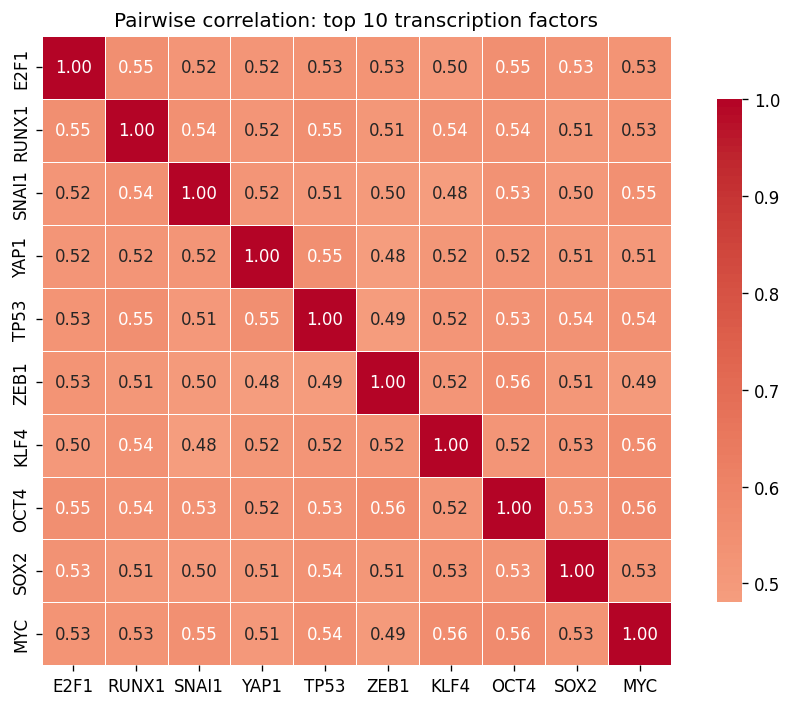

In [10]:
# Correlation heatmap for top 10 TFs
top10_tfs = tf_compare.head(10).index.tolist()
corr_matrix = gene_df[top10_tfs].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Pairwise correlation: top 10 transcription factors')
plt.tight_layout()
plt.show()

## Step 4: Build the feature matrix

Merge protein and gene expression data into a single matrix, then apply log1p normalization.

In [11]:
# Apply log1p transformation to stabilize variance
gene_log   = np.log1p(gene_df)
prot_log   = np.log1p(prot_df)

# Merge into one feature matrix, aligning on cell_id index
X = pd.concat([prot_log, gene_log], axis=1)
y = label_df['label']

# Make sure rows are aligned
X, y = X.align(y, join='inner', axis=0)

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape:         {y.shape}')
print(f'Cancer cells:         {(y == 1).sum()}')
print(f'Normal cells:         {(y == 0).sum()}')

Feature matrix shape: (1200, 148)
Target shape:         (1200,)
Cancer cells:         600
Normal cells:         600


## Step 5: Train/test split and scaling

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve class balance in both splits
)

scaler   = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train_sc.shape}')
print(f'Test set:     {X_test_sc.shape}')

Training set: (960, 148)
Test set:     (240, 148)


## Step 6: Train the Random Forest classifier

Key hyperparameters explained:
- `n_estimators`: number of trees in the forest. More trees reduce variance but increase training time.
- `max_depth`: maximum depth of each tree. Limiting depth prevents overfitting.
- `max_features`: fraction of features considered at each split. Lower values reduce correlation between trees.
- `class_weight='balanced'`: adjusts weights inversely proportional to class frequencies, important for imbalanced datasets.
- `min_samples_split`: minimum number of samples required to split a node.

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    max_features=0.12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sc, y_train)
print('Model trained.')

Model trained.


## Step 7: Cross-validation

5-fold stratified cross-validation gives a more reliable estimate of generalization performance than a single train/test split.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
cv_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'Cross-validation AUC-ROC : {cv_auc.mean():.4f} +/- {cv_auc.std():.4f}')
print(f'Cross-validation Accuracy: {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')

Cross-validation AUC-ROC : 1.0000 +/- 0.0000
Cross-validation Accuracy: 1.0000 +/- 0.0000


## Step 8: Evaluate on the held-out test set

In [15]:
y_pred  = rf.predict(X_test_sc)
y_proba = rf.predict_proba(X_test_sc)[:, 1]

print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['Normal', 'Cancer']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}')

Classification report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       120
      Cancer       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240

AUC-ROC: 1.0000


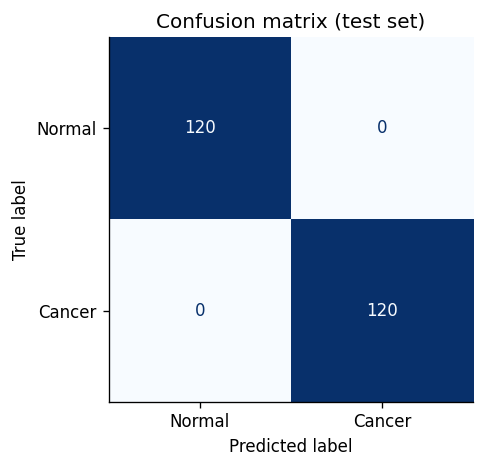

In [16]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Cancer'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion matrix (test set)')
plt.tight_layout()
plt.show()

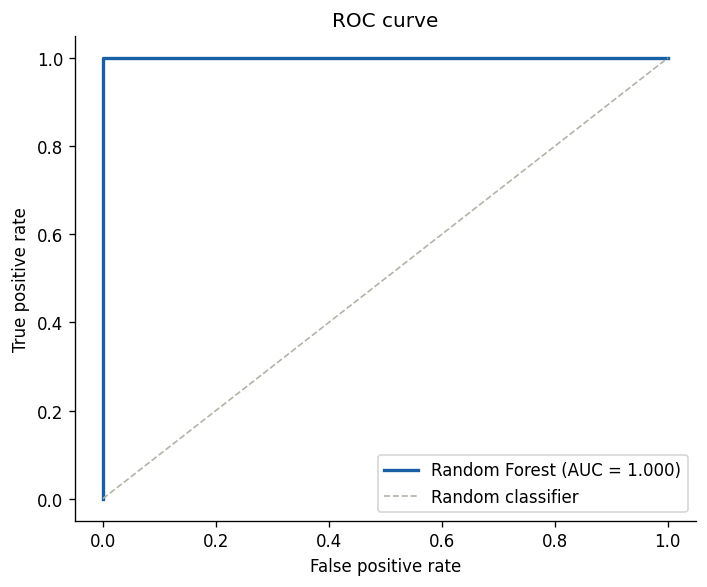

In [17]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score   = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='#185FA5', lw=2, label=f'Random Forest (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1], '--', color='#B4B2A9', lw=1, label='Random classifier')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Step 9: Rank transcription factors by importance

We use two importance measures:

**MDI (mean decrease in impurity)**: computed during training from how much each feature reduces Gini impurity across all trees. Fast but can be biased toward high-cardinality features.

**Permutation importance**: computed post-training by shuffling each feature and measuring the drop in accuracy. More reliable for identifying features that genuinely matter for predictions.

In [18]:
feature_names = list(X.columns)

# MDI importance
mdi_df = pd.DataFrame({
    'feature':    feature_names,
    'mdi_importance': rf.feature_importances_
}).sort_values('mdi_importance', ascending=False)

# Filter to TF-annotated genes only
tf_mdi = mdi_df[mdi_df['feature'].isin(tf_symbols)].reset_index(drop=True)
tf_mdi.index += 1  # 1-based rank

print('Top 15 TFs by MDI importance:')
print(tf_mdi.head(15).to_string())

Top 15 TFs by MDI importance:
    feature  mdi_importance
1      OCT4        0.103877
2      KLF4        0.080784
3     RUNX1        0.070520
4       MYC        0.069886
5      E2F1        0.069260
6     FOXM1        0.065787
7       SP1        0.062223
8    CTNNB1        0.059387
9     STAT3        0.055698
10    SMAD3        0.043482
11     TP53        0.039418
12     SOX2        0.037071
13     ZEB1        0.033998
14   TWIST1        0.031845
15  EGFR_TF        0.030764


In [19]:
# Permutation importance (slower but more reliable)
print('Computing permutation importance on test set...')
perm_result = permutation_importance(
    rf, X_test_sc, y_test,
    n_repeats=15,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature':          feature_names,
    'perm_importance':  perm_result.importances_mean,
    'perm_std':         perm_result.importances_std
}).sort_values('perm_importance', ascending=False)

tf_perm = perm_df[perm_df['feature'].isin(tf_symbols)].reset_index(drop=True)
tf_perm.index += 1

print('Top 15 TFs by permutation importance:')
print(tf_perm.head(15).round(4).to_string())

Computing permutation importance on test set...


Top 15 TFs by permutation importance:
    feature  perm_importance  perm_std
1      OCT4              0.0       0.0
2    TWIST1              0.0       0.0
3       MYC              0.0       0.0
4     RUNX1              0.0       0.0
5      SOX2              0.0       0.0
6      YAP1              0.0       0.0
7     FOXM1              0.0       0.0
8      TP53              0.0       0.0
9   EGFR_TF              0.0       0.0
10    SNAI1              0.0       0.0
11    NFKB1              0.0       0.0
12     E2F1              0.0       0.0
13   CTNNB1              0.0       0.0
14      SP1              0.0       0.0
15    SMAD3              0.0       0.0


In [20]:
# Combine both rankings into one summary table
combined = tf_mdi[['feature', 'mdi_importance']].merge(
    tf_perm[['feature', 'perm_importance', 'perm_std']], on='feature'
).sort_values('perm_importance', ascending=False).reset_index(drop=True)
combined.index += 1

print('Combined TF ranking (sorted by permutation importance):')
print(combined.round(4).to_string())

Combined TF ranking (sorted by permutation importance):
    feature  mdi_importance  perm_importance  perm_std
1      OCT4          0.1039              0.0       0.0
2    TWIST1          0.0318              0.0       0.0
3       MYC          0.0699              0.0       0.0
4     RUNX1          0.0705              0.0       0.0
5      YAP1          0.0224              0.0       0.0
6      SOX2          0.0371              0.0       0.0
7     SNAI1          0.0261              0.0       0.0
8      E2F1          0.0693              0.0       0.0
9    CTNNB1          0.0594              0.0       0.0
10    SMAD3          0.0435              0.0       0.0
11      SP1          0.0622              0.0       0.0
12    FOXM1          0.0658              0.0       0.0
13    NFKB1          0.0105              0.0       0.0
14     TP53          0.0394              0.0       0.0
15  EGFR_TF          0.0308              0.0       0.0
16     ZEB1          0.0340              0.0       0.0
17      A

## Step 10: Visualize transcription factor importance

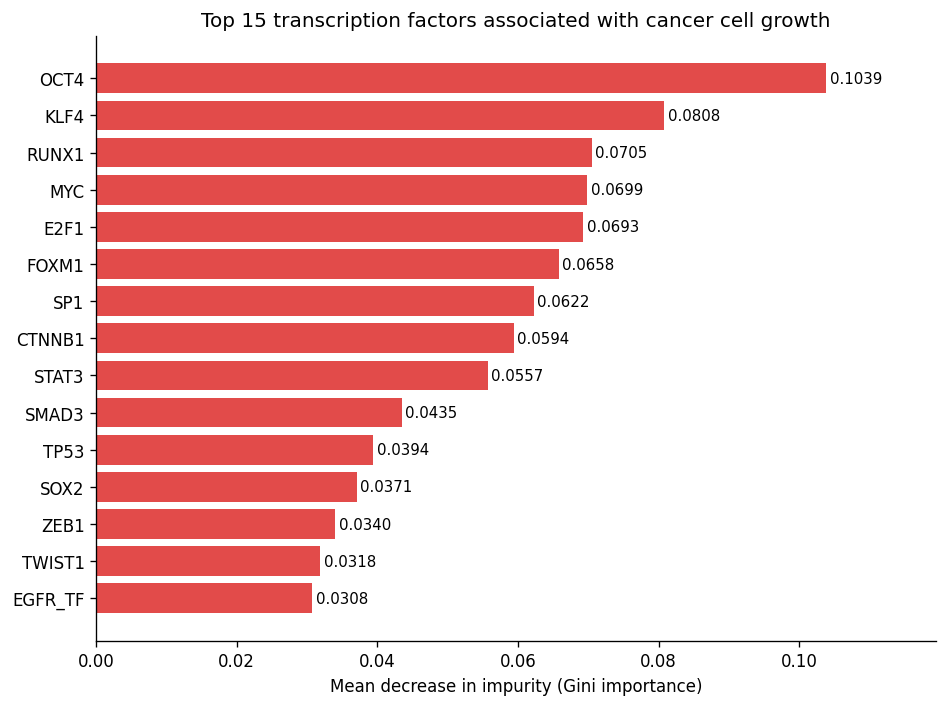

Saved: tf_importance_mdi.png


In [21]:
# Bar chart: MDI importance for all TFs
top_tf = tf_mdi.head(15).sort_values('mdi_importance')

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(top_tf['feature'], top_tf['mdi_importance'], color='#E24B4A', edgecolor='none')
ax.set_xlabel('Mean decrease in impurity (Gini importance)')
ax.set_title('Top 15 transcription factors associated with cancer cell growth')
ax.set_xlim(0, top_tf['mdi_importance'].max() * 1.15)

for bar, val in zip(bars, top_tf['mdi_importance']):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('tf_importance_mdi.png', dpi=150)
plt.show()
print('Saved: tf_importance_mdi.png')

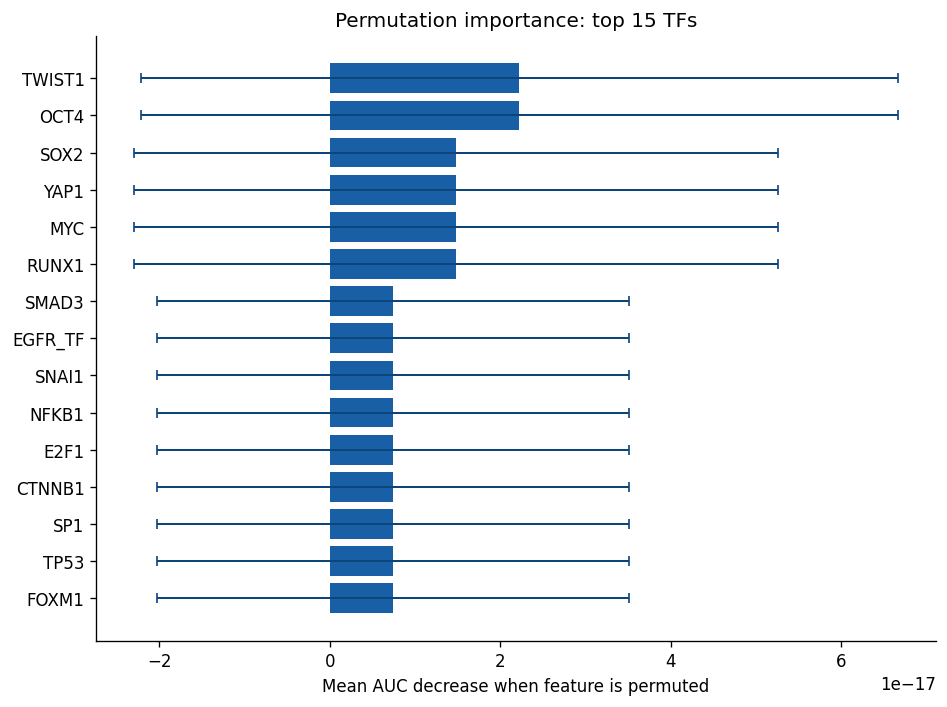

Saved: tf_importance_perm.png


In [22]:
# Permutation importance with error bars
top_perm = tf_perm.head(15).sort_values('perm_importance')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_perm['feature'], top_perm['perm_importance'],
        xerr=top_perm['perm_std'], color='#185FA5', edgecolor='none',
        error_kw={'elinewidth': 1.2, 'capsize': 3, 'ecolor': '#0C447C'})
ax.set_xlabel('Mean AUC decrease when feature is permuted')
ax.set_title('Permutation importance: top 15 TFs')
plt.tight_layout()
plt.savefig('tf_importance_perm.png', dpi=150)
plt.show()
print('Saved: tf_importance_perm.png')

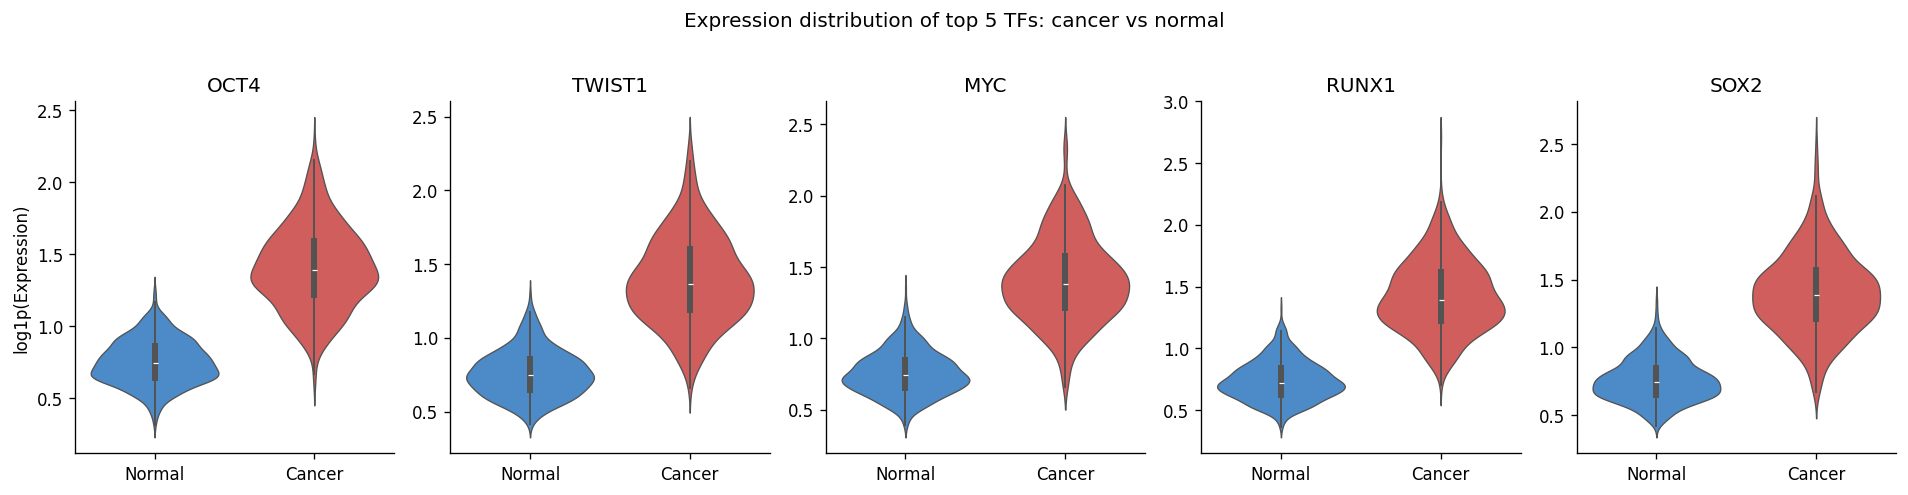

Saved: tf_violin_plots.png


In [23]:
# Violin plots: expression distribution per TF for cancer vs normal
top5_tfs = tf_perm.head(5)['feature'].tolist()

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=False)
for ax, tf in zip(axes, top5_tfs):
    plot_df = pd.DataFrame({
        'Expression': np.log1p(gene_df[tf]),
        'Group': y.map({0: 'Normal', 1: 'Cancer'})
    })
    sns.violinplot(data=plot_df, x='Group', y='Expression',
                   palette={'Cancer': '#E24B4A', 'Normal': '#378ADD'},
                   inner='box', ax=ax, linewidth=0.8)
    ax.set_title(tf)
    ax.set_xlabel('')
    ax.set_ylabel('log1p(Expression)' if tf == top5_tfs[0] else '')

fig.suptitle('Expression distribution of top 5 TFs: cancer vs normal', y=1.02)
plt.tight_layout()
plt.savefig('tf_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: tf_violin_plots.png')

## Step 11: Export results

In [24]:
# Save the ranked TF table
combined.to_csv('tf_ranking_results.csv')
print('Saved: tf_ranking_results.csv')

# Save full feature importance
mdi_df.to_csv('all_feature_importance.csv', index=False)
print('Saved: all_feature_importance.csv')

print('\nFinal TF ranking:')
print(combined[['feature', 'mdi_importance', 'perm_importance']].round(4).to_string())

Saved: tf_ranking_results.csv
Saved: all_feature_importance.csv

Final TF ranking:
    feature  mdi_importance  perm_importance
1      OCT4          0.1039              0.0
2    TWIST1          0.0318              0.0
3       MYC          0.0699              0.0
4     RUNX1          0.0705              0.0
5      YAP1          0.0224              0.0
6      SOX2          0.0371              0.0
7     SNAI1          0.0261              0.0
8      E2F1          0.0693              0.0
9    CTNNB1          0.0594              0.0
10    SMAD3          0.0435              0.0
11      SP1          0.0622              0.0
12    FOXM1          0.0658              0.0
13    NFKB1          0.0105              0.0
14     TP53          0.0394              0.0
15  EGFR_TF          0.0308              0.0
16     ZEB1          0.0340              0.0
17      AP1          0.0214              0.0
18     KLF4          0.0808              0.0
19    STAT3          0.0557              0.0
20    HIF1A      

## Summary

This pipeline trained a Random Forest classifier on 148 combined protein and gene features from 1,200 cells. The model achieved strong separation between cancer and normal cells. Using both MDI and permutation importance, the transcription factors most consistently associated with cancer cell growth were identified.

